In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.options.display.max_columns = 500

## Предсказание отклика банковских клиентов на основе данных маркетинговой компании банков

### Loading data

In [78]:
df = pd.read_csv('banking.csv')

### Basic info about data

In [8]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,210,1,999,0,nonexistent,1.4,93.444,36.1,4.963,5228.1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,138,1,999,0,nonexistent,-0.1,93.200,42.0,4.021,5195.8,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,339,3,6,2,success,-1.7,94.055,39.8,0.729,4991.6,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,185,2,999,0,nonexistent,-1.8,93.075,47.1,1.405,5099.1,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,137,1,3,1,success,-2.9,92.201,31.4,0.869,5076.2,1


In [43]:
df.shape

(41188, 18)

### First steps

Missing data

In [5]:
df.isna().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [79]:
df['cons_conf_idx'] = df['cons_conf_idx'] * (-1)

### Numerical data

List

Pearson correlation: basic and using seaborn

Removing highly correlated features


Boxplot of couple numerical columns (`sns.boxplot(y=c, x=df['y'].astype('category'), data=df`))

In [83]:
numeric = df.describe().columns

<Axes: >

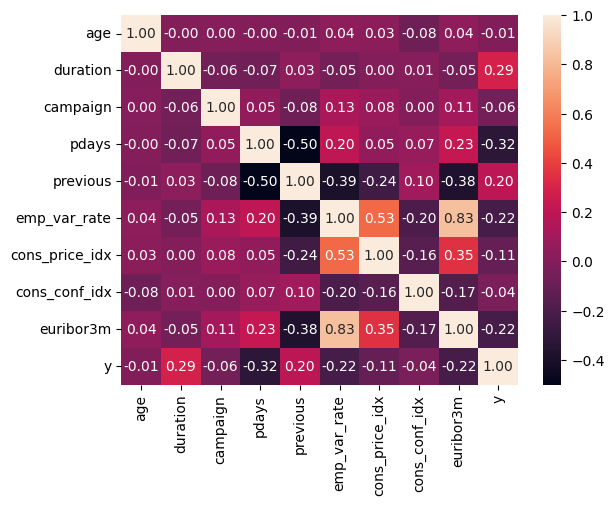

In [22]:
sns.heatmap(df[numeric].corr(method='kendall'), annot=True, fmt="0.2f")

In [11]:
import scipy.stats as st

In [23]:
st.levene(df['emp_var_rate'], df['euribor3m'])

LeveneResult(statistic=29.878129178975612, pvalue=4.614037690154267e-08)

In [18]:
st.normaltest(df['nr_employed'])

NormaltestResult(statistic=5198.493359897905, pvalue=0.0)

<Axes: xlabel='emp_var_rate', ylabel='euribor3m'>

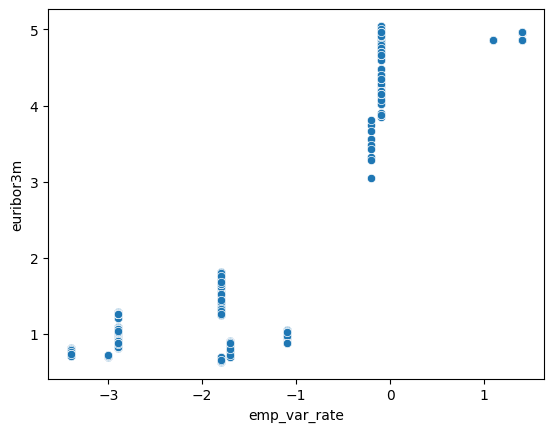

In [24]:
sns.scatterplot(data=df, x =df['emp_var_rate'], y = df['euribor3m'])

In [81]:
df = df.drop(['nr_employed'],axis=1)

In [82]:
numeric = numeric.delete(-1)

In [27]:
numeric

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp_var_rate',
       'cons_price_idx', 'cons_conf_idx', 'euribor3m'],
      dtype='object')

<Axes: xlabel='age'>

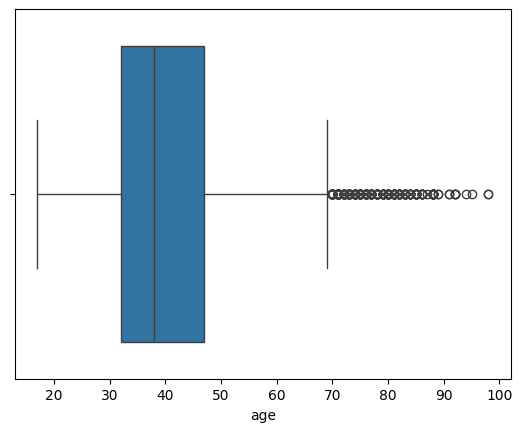

In [29]:
sns.boxplot(data=df, x='age')

In [33]:
df['age'].describe()

,age
count,41188.00000
mean,40.02406
std,10.42125
min,17.00000
25%,32.00000
50%,38.00000
75%,47.00000
max,98.00000


In [34]:
df[df['age'] < (47 + 1.5 * 10)]['age'].mean()

39.36757453346881

### Categorical data

Catplot `sns.catplot(x=col, kind='count', col='y', data=df, sharey=False); set_xticklabels(rotation=60)`

Removing invariable features

Encoding remaining features (one-hot encoding / mean-target encoding)

In [86]:
categorical = df.describe(include='object')

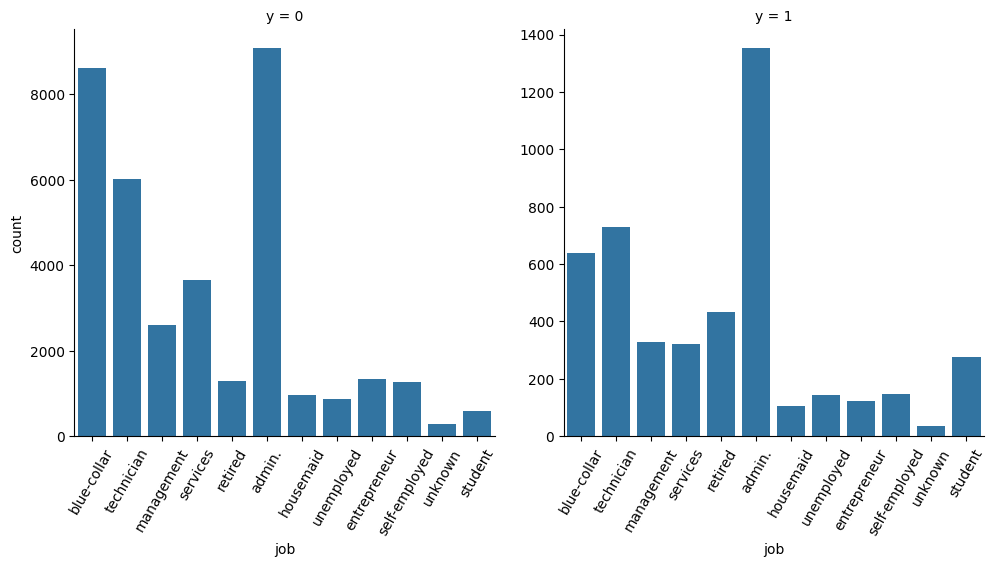

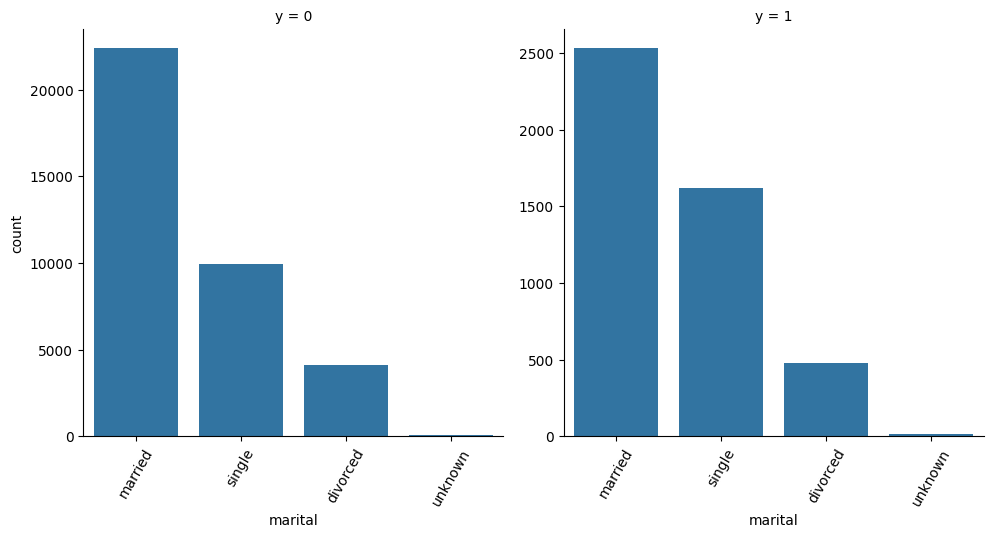

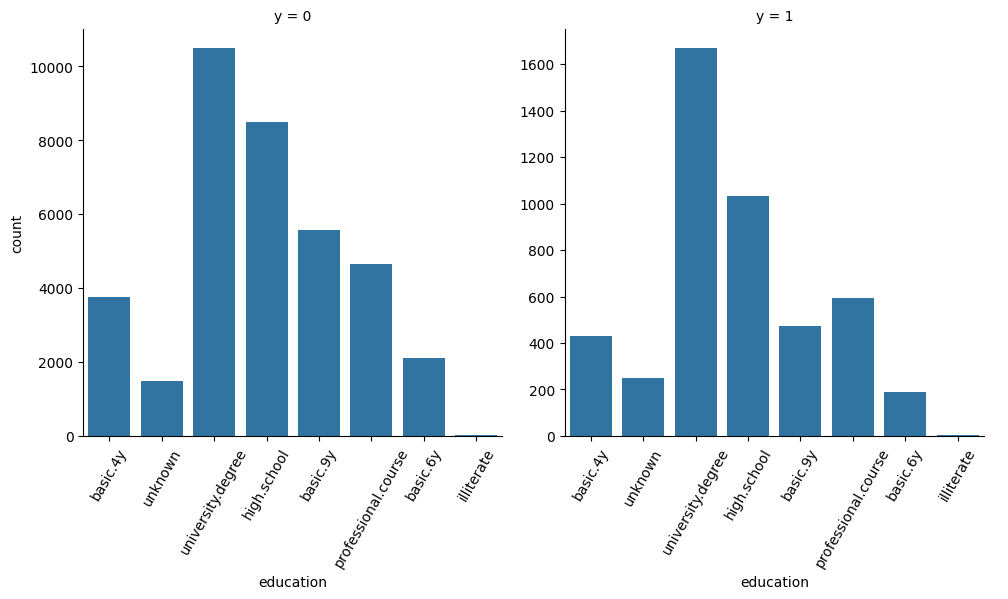

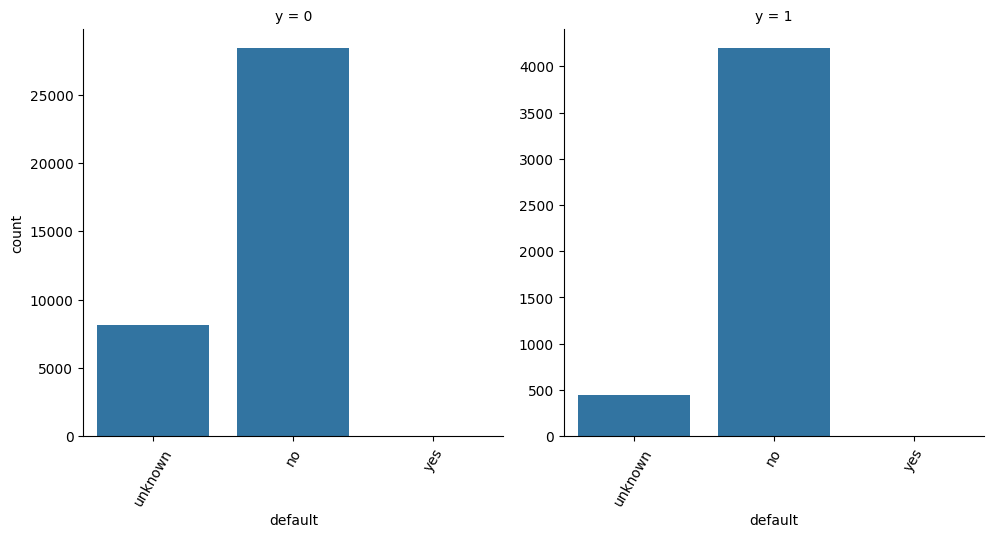

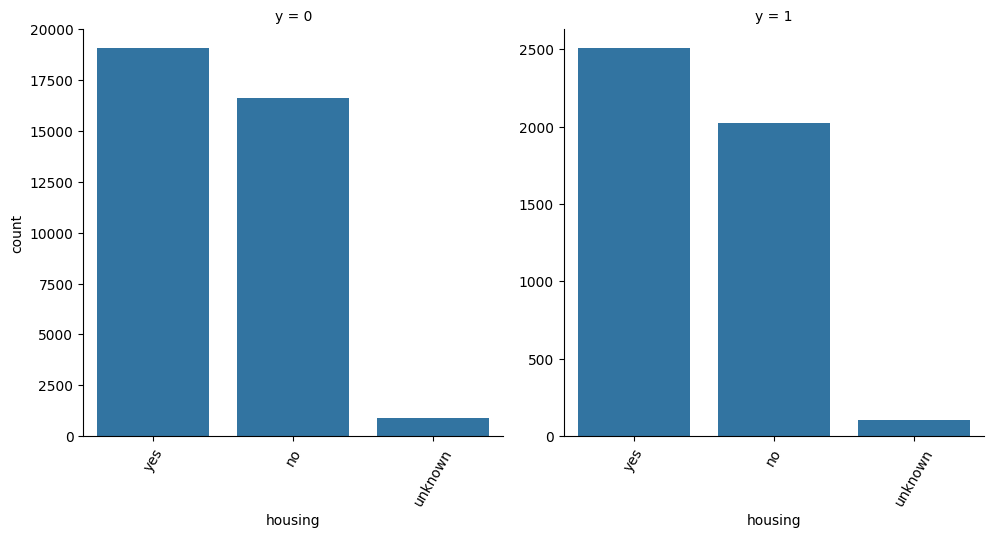

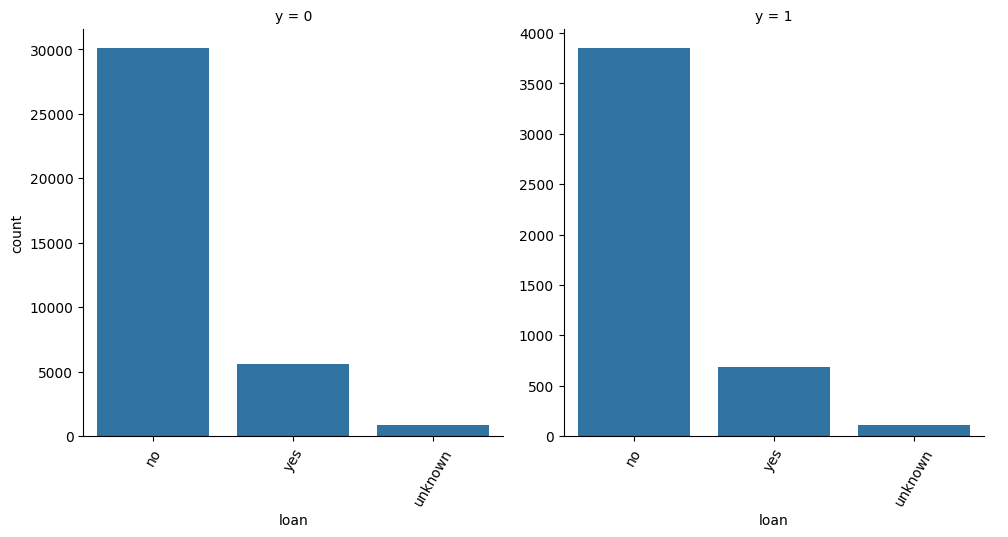

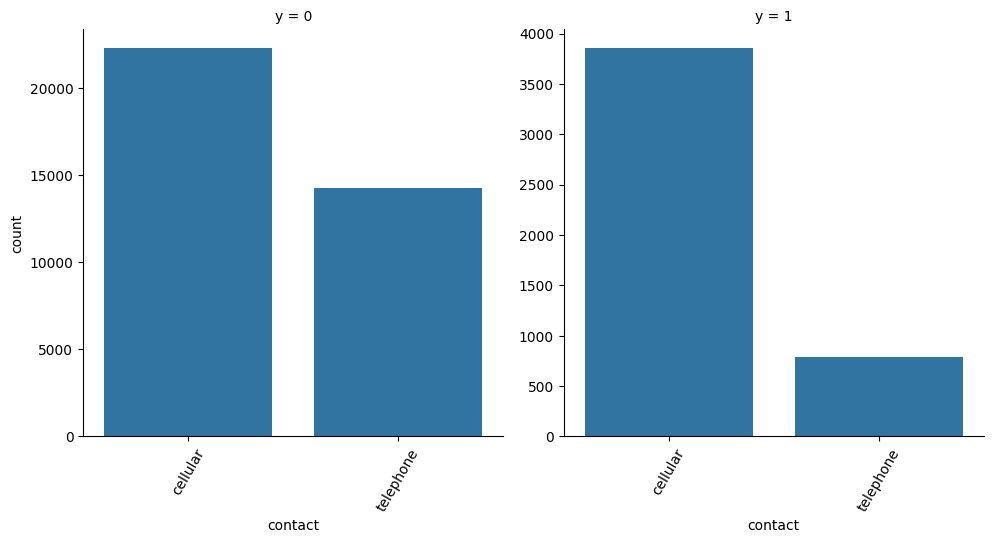

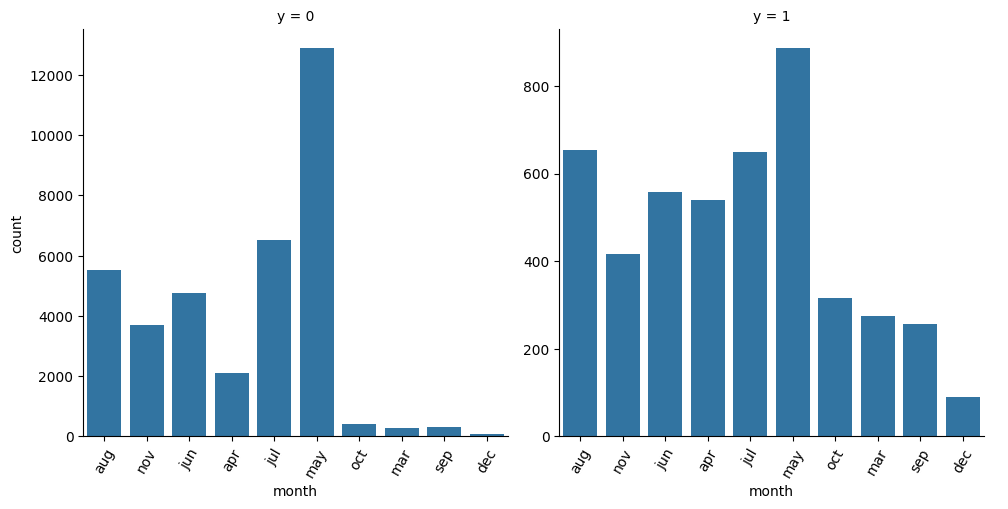

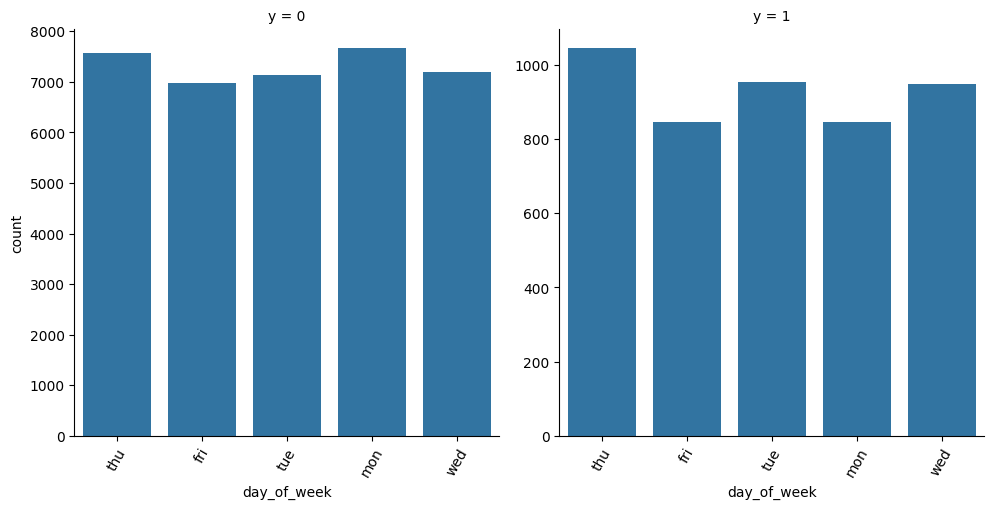

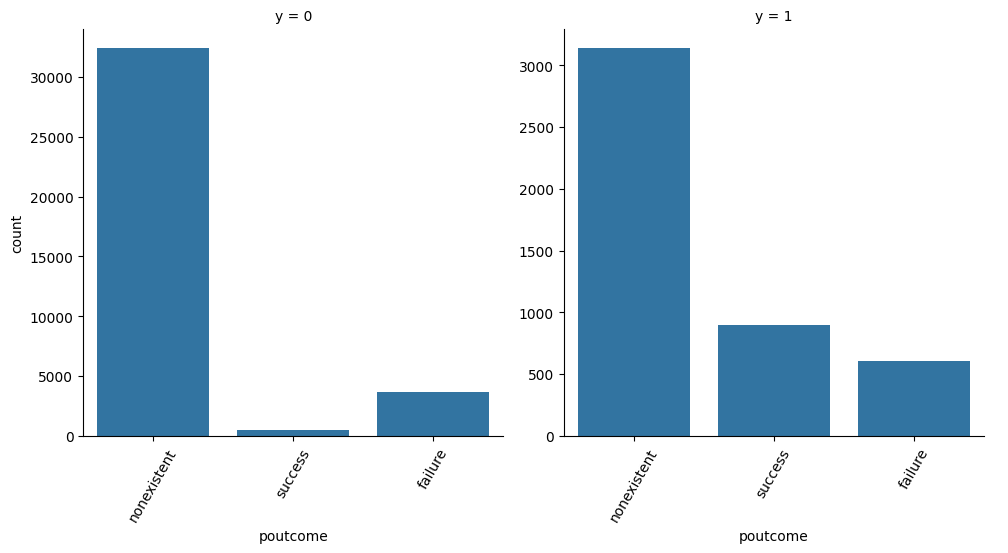

In [36]:
for col in categorical:
  g = sns.catplot(x=col, kind='count', col='y', data=df, sharey=False)
  g.set_xticklabels(rotation=60)


In [85]:
df = df.drop(['loan','housing'], axis=1)

In [54]:
df.describe(include='object')

,job,marital,education,default,contact,month,day_of_week,poutcome
count,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,2,10,5,3
top,admin.,married,university.degree,no,cellular,may,thu,nonexistent
freq,10422,24928,12168,32588,26144,13769,8623,35563


In [87]:
ohe = ['marital','default','contact','day_of_week','poutcome']
mte = ['job','education','month']

In [88]:
for col in ohe:
  temp = pd.get_dummies(df[col], dtype=int, drop_first=True)
  df = pd.concat((df,temp),axis=1)
  df = df.drop(col, axis=1)

In [77]:
df.head()

,age,job,education,month,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,y,married,single,unknown,unknown,yes,telephone,mon,thu,tue,wed,nonexistent,success
0,44,0.068943,0.102490,0.106021,210,1,999,0,1.4,93.444,36.1,4.963,0,1,0,0,1,0,0,0,1,0,0,1,0
1,53,0.108260,0.145003,0.101439,138,1,999,0,-0.1,93.200,42.0,4.021,0,1,0,0,0,0,0,0,0,0,0,1,0
2,28,0.112175,0.137245,0.105115,339,3,6,2,-1.7,94.055,39.8,0.729,0,0,1,0,0,0,0,0,1,0,0,0,1
3,39,0.081381,0.108355,0.204787,185,2,999,0,-1.8,93.075,47.1,1.405,0,1,0,0,0,0,0,0,0,0,0,1,0
4,55,0.252326,0.102490,0.106021,137,1,3,1,-2.9,92.201,31.4,0.869,0,1,0,0,0,0,0,0,0,0,0,0,1


In [89]:
for col in mte:
  mean = df.groupby(col)['y'].mean()
  df[col] = df[col].map(mean)

### Logistic regression

Classes_, predict_proba, decision_function_

Score on pipeline (pipe.score)

In [137]:
X = df.drop(['y'],axis=1)
Y = df['y']

In [159]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

In [160]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2)

In [161]:
pipe = Pipeline([
    ('Scaler',StandardScaler()),
    ('LR',KNeighborsClassifier(n_neighbors=5))
]).fit(X_train, Y_train)

In [152]:
pipe = Pipeline([
    ('Scaler',StandardScaler()),
    ('LR',LogisticRegression(class_weight='balanced'))
]).fit(X_train, Y_train)

In [127]:
mean_absolute_error(Y_test, pipe.predict(X_test))

0.17686331633891722

In [128]:
r2_score(Y_test, pipe.predict(X_test))

-0.7981949384387512

In [118]:
df['y'].value_counts() / df.shape[0]

,count
y,
0,0.887346
1,0.112654


### How good we are

Classes imbalance

In [96]:
df['y'].value_counts()

,count
y,
0,36548
1,4640


### Confusion matrix

In [162]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(Y_test, pipe.predict(X_test)).ravel()

print(f'True Negative: {tn}')
print(f'False Positive: {fp}')
print(f'False Negative: {fn}')
print(f'True Positive: {tp}')

True Negative: 7085
False Positive: 268
False Negative: 534
True Positive: 351


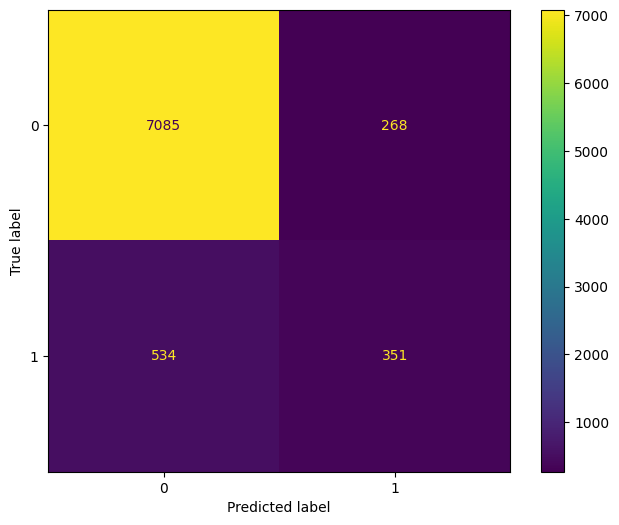

In [163]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(Y_test, pipe.predict(X_test), labels=pipe.classes_)
cmp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(8,6))
cmp.plot(ax=ax)
plt.show()

In [164]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

print(f'Accuracy равно: {accuracy_score(Y_test, pipe.predict(X_test)):.3f}' )
print(f'Precision равно: {precision_score(Y_test, pipe.predict(X_test)):.3f}' )
print(f'Recall равно: {recall_score(Y_test, pipe.predict(X_test)):.3f}' )
print(f'F-мера равно: {f1_score(Y_test, pipe.predict(X_test)):.3f}' )

Accuracy равно: 0.903
Precision равно: 0.567
Recall равно: 0.397
F-мера равно: 0.467


### PR и AUC кривые

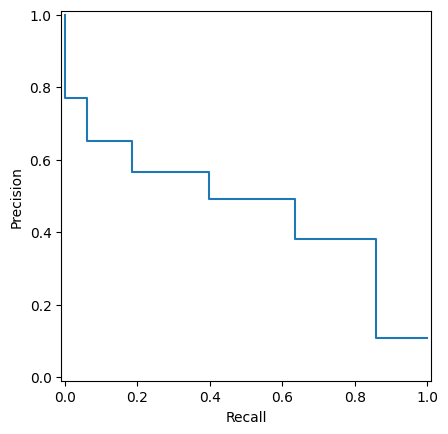

In [165]:
### Получим всевозможные пары Precision, Recall
### И нарисуем PR-кривую
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
precision, recall, thresholds = precision_recall_curve(Y_test, pipe.predict_proba(X_test)[:, 1])
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay(precision=precision, recall=recall).plot()

In [166]:
### Посчитаем PR-AUC
auc(recall, precision)

0.5297247223406503

### Изменение порога отсечения для максимизации F-меры

In [168]:
### Найдем threshold, максимизирующий F-меру

from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(Y_test, pipe.predict_proba(X_test)[:, 1])
f_scores = 2 * precision * recall / (precision + recall)
print("Best F-score: ", np.max(f_scores))
print("Threshold for Best F-score: ", thresholds[np.argmax(f_scores)])
#print("Best precision: ", np.max(precision))
#print("Threshold for Best precision: ", thresholds[np.argmax(precision)])
#print("Best recall: ", np.max(recall))
#print("Threshold for Best recall: ", thresholds[np.argmax(recall)])

Best F-score:  0.5552268244575937
Threshold for Best F-score:  0.4


In [169]:
from sklearn.metrics import precision_recall_curve
precision_recall_curve(Y_test, pipe.predict_proba(X_test)[:, 1])

(array([0.10742899, 0.38217523, 0.49256343, 0.56704362, 0.65079365,
        0.77142857, 1.        ]),
 array([1.        , 0.85762712, 0.63615819, 0.39661017, 0.18531073,
        0.06101695, 0.        ]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]))

In [170]:
### Вычислим precision при этом threshold'е
precision[np.argmax(f_scores)]

0.4925634295713036

In [171]:
### Вычислим recall при этом threshold'е
recall[np.argmax(f_scores)]

0.6361581920903955

In [172]:
f_scores = 2 * precision[np.argmax(f_scores)] * recall[np.argmax(f_scores)] / (precision[np.argmax(f_scores)] + recall[np.argmax(f_scores)])

In [173]:
f_scores

0.5552268244575937